### *ETAPA 5 KPIs y métricas de seguimiento*

#### Objetivo

Analizar los principales indicadores de negocio que permitan monitorear el cumplimiento del objetivo estratégico de incrementar en un 50 % las comisiones generadas por la API de pagos.

Los KPIs propuestos están alineados con la segmentación realizada y buscan medir tanto el crecimiento de las ventas como la evolución del uso de la plataforma por parte de los comercios.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [30]:
# ==========================================
# Cargar dataset segmentado
# ==========================================

from pathlib import Path

ruta = Path("../data/processed/segmentacion_final.xlsx")

segmentacion = pd.read_excel(ruta)

print(f"Comercios: {len(segmentacion):,}")

display(segmentacion.head())

Comercios: 3,015


,Id_comercio,frecuencia,Monto ventas Acumulado,Monto ventas ultimo mes,frecuencia_norm,ventas_acumuladas_norm,ventas_mes_norm,business_score,segmento
0,003QDVFJCJ,30,6542000,1240000,0.04,0.06,0.04,0.05,Alto potencial
1,008LJH6YHN,10,4380000,1102000,0.01,0.04,0.03,0.03,En desarrollo
2,00B3DGV62G,65,11892500,1297000,0.09,0.11,0.04,0.09,Estratégico
3,00ILW1BB3Y,8,372500,74500,0.01,0.00,0.00,0.01,Baja actividad
4,01AK7UX4UU,4,165500,0,0.00,0.00,0.00,0.00,Baja actividad


#### *KPI 1 Ventas Totales*

Representa el volumen total de ventas procesadas por la plataforma.

Es el principal impulsor de las comisiones, ya que la empresa obtiene el 5 % del valor transaccionado.

In [31]:
# ==========================================
# KPI 1
# ==========================================

ventas_totales = segmentacion["Monto ventas Acumulado"].sum()

print(f"Ventas Totales: ${ventas_totales:,.0f}")

Ventas Totales: $13,230,650,332


#### *KPI 2 Comisión total*

Corresponde al ingreso esperado para la compañía considerando una comisión del 5 % sobre todas las ventas.

In [32]:
# ==========================================
# KPI 2
# ==========================================

comision = ventas_totales * 0.05

print(f"Comisión total: ${comision:,.0f}")

Comisión total: $661,532,517


#### *KPI 3 Ventas último mes*

Permite monitorear el comportamiento reciente de las ventas y detectar si el negocio mantiene una tendencia de crecimiento.

In [33]:
# ==========================================
# KPI 3
# ==========================================

ventas_mes = segmentacion["Monto ventas ultimo mes"].sum()

print(f"Ventas último mes: ${ventas_mes:,.0f}")

Ventas último mes: $2,019,326,150


#### *KPI 4 Comisión último mes*

In [34]:
# ==========================================
# KPI 4
# ==========================================

comision_mes = ventas_mes * 0.05

print(f"Comisión último mes: ${comision_mes:,.0f}")

Comisión último mes: $100,966,308


#### *KPI 5 Comercios activos*

Número de comercios que registraron al menos una venta durante el último mes.

In [35]:
# ==========================================
# KPI 5
# ==========================================

activos = (
    segmentacion["Monto ventas ultimo mes"] > 0
).sum()

print(f"Comercios activos: {activos:,}")

Comercios activos: 1,782


#### *KPI 6 Ticket promedio por comercio*

Mide el valor promedio vendido por cada comercio activo.

In [36]:
# ==========================================
# KPI 6
# ==========================================

ticket = (
    segmentacion.loc[
        segmentacion["Monto ventas ultimo mes"]>0,
        "Monto ventas ultimo mes"
    ].mean()
)

print(f"Ticket promedio: ${ticket:,.0f}")

Ticket promedio: $1,133,180


#### *KPI 7 Frecuencia promedio*

Cantidad promedio de transacciones realizadas por comercio.

In [37]:
# ==========================================
# KPI 7
# ==========================================

frecuencia = segmentacion["frecuencia"].mean()

print(f"Frecuencia promedio: {frecuencia:.2f}")

Frecuencia promedio: 22.60


#### *KPI 8 Participación por segmento*

Este KPI conecta directamente la segmentación con el negocio.

In [38]:
# ==========================================
# KPI 8
# ==========================================

participacion = (
    segmentacion
    .groupby("segmento")
    ["Monto ventas ultimo mes"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

participacion["Participación (%)"] = (
    participacion["Monto ventas ultimo mes"]
    / participacion["Monto ventas ultimo mes"].sum()
    *100
)

display(participacion)

,Monto ventas ultimo mes,Participación (%)
segmento,,
Estratégico,985931857,48.82
Alto potencial,672487383,33.30
En desarrollo,317246780,15.71
Baja actividad,43660130,2.16


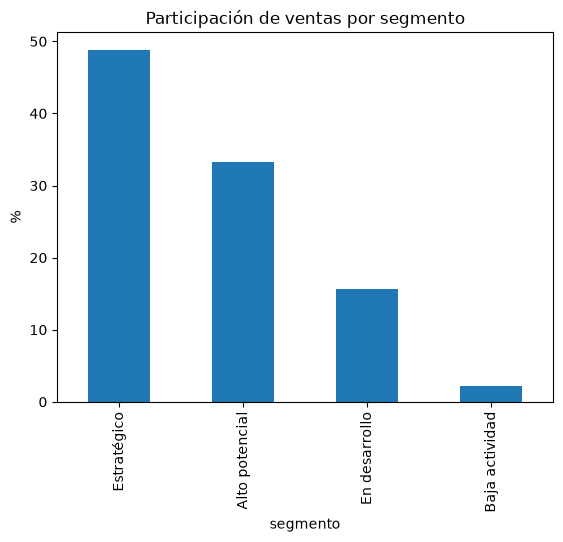

In [39]:
# ==========================================
# Participación de ventas por segmento
# ==========================================

import matplotlib.pyplot as plt

participacion["Participación (%)"].plot(
    kind="bar"
)

plt.title("Participación de ventas por segmento")

plt.ylabel("%")

plt.show()

In [40]:
# ==========================================
# KPIs recomendados para seguimiento
# ==========================================

kpis = pd.DataFrame({
    "KPI":[
        "Ventas Totales",
        "Comisión estimada",
        "Ventas último mes",
        "Comisión último mes",
        "Comercios activos",
        "Ticket promedio",
        "Frecuencia promedio",
        "% ventas segmento estratégico"
    ],
    "Objetivo":[
        "Incrementar",
        "Incrementar",
        "Incrementar",
        "Incrementar",
        "Incrementar",
        "Incrementar",
        "Incrementar",
        "Incrementar"
    ],
    "Periodicidad":[
        "Mensual",
        "Mensual",
        "Mensual",
        "Mensual",
        "Mensual",
        "Mensual",
        "Mensual",
        "Mensual"
    ]
})

display(kpis)

,KPI,Objetivo,Periodicidad
0,Ventas Totales,Incrementar,Mensual
1,Comisión estimada,Incrementar,Mensual
2,Ventas último mes,Incrementar,Mensual
3,Comisión último mes,Incrementar,Mensual
4,Comercios activos,Incrementar,Mensual
5,Ticket promedio,Incrementar,Mensual
6,Frecuencia promedio,Incrementar,Mensual
7,% ventas segmento estratégico,Incrementar,Mensual


#### Interpretación

Los indicadores seleccionados permiten monitorear de manera directa el objetivo estratégico del negocio.

Las ventas totales y la comisión estimada reflejan el resultado económico esperado para la compañía, mientras que las ventas del último mes permiten evaluar la evolución reciente del negocio.

Los comercios activos, la frecuencia de uso y el ticket promedio ayudan a identificar si el crecimiento proviene de una mayor adopción de la plataforma o de un mayor volumen de ventas por comercio.

Finalmente, la participación de ventas por segmento permite evaluar el impacto de las estrategias comerciales sobre los grupos definidos en la segmentación. Un aumento en la participación del segmento Estratégico o el crecimiento de comercios desde Alto Potencial hacia Estratégico serían señales positivas para alcanzar el objetivo de incrementar las comisiones generadas por la API.